# IBM HR Analytics — Employee Attrition Prediction
**Author:** Thallada Shiva Sai  
**Dataset:** IBM HR Analytics Employee Attrition & Performance  
**Goal:** Predict which employees are likely to leave the company using Machine Learning


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print('✅ Libraries loaded successfully!')

✅ Libraries loaded successfully!


## 2. Load & Explore Dataset

In [2]:
df = pd.read_excel('WA_Fn-UseC_-HR-Employee-Attrition_csv.xlsx')
print(f'Dataset Shape: {df.shape}')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')
df.head()

Dataset Shape: (1470, 35)
Rows: 1470, Columns: 35


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
print('--- Dataset Info ---')
print(f'Missing Values: {df.isnull().sum().sum()}')
print(f'Duplicate Rows: {df.duplicated().sum()}')
print('\n--- Data Types ---')
print(df.dtypes.value_counts())
df.describe()

--- Dataset Info ---
Missing Values: 0
Duplicate Rows: 0

--- Data Types ---
int64    26
str       9
Name: count, dtype: int64


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


## 3. Exploratory Data Analysis (EDA)

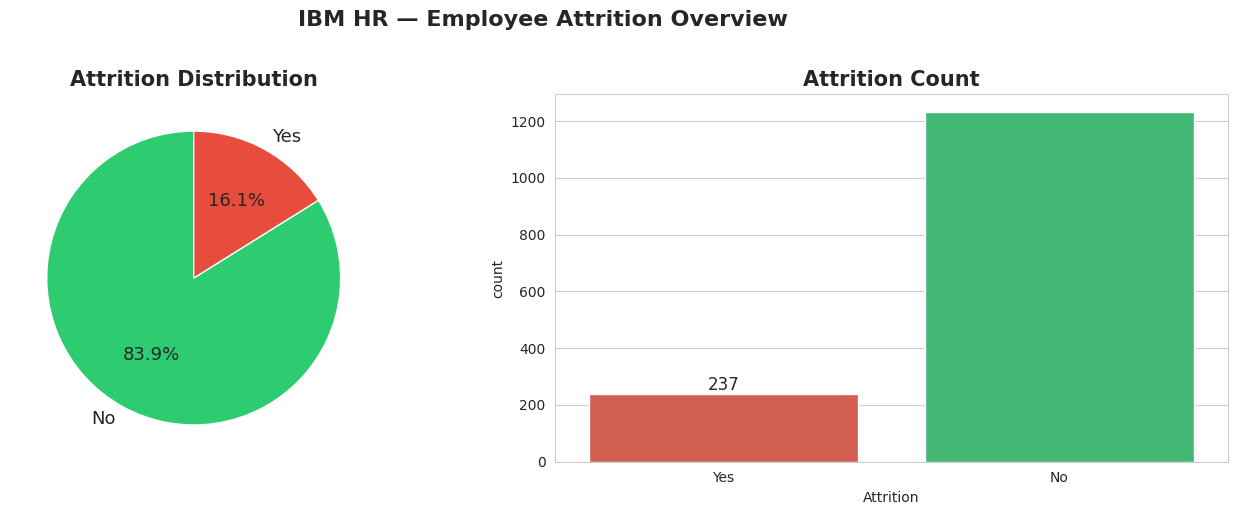

Attrition Rate: 16.1%


In [4]:
# Attrition Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['Attrition'].value_counts()
colors = ['#2ecc71', '#e74c3c']

axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 13})
axes[0].set_title('Attrition Distribution', fontsize=15, fontweight='bold')

sns.countplot(data=df, x='Attrition', palette={'No': '#2ecc71', 'Yes': '#e74c3c'}, ax=axes[1])
axes[1].set_title('Attrition Count', fontsize=15, fontweight='bold')
axes[1].bar_label(axes[1].containers[0], fontsize=12)

plt.suptitle('IBM HR — Employee Attrition Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('attrition_overview.png', bbox_inches='tight', dpi=150)
plt.show()
print(f'Attrition Rate: {counts["Yes"]/len(df)*100:.1f}%')

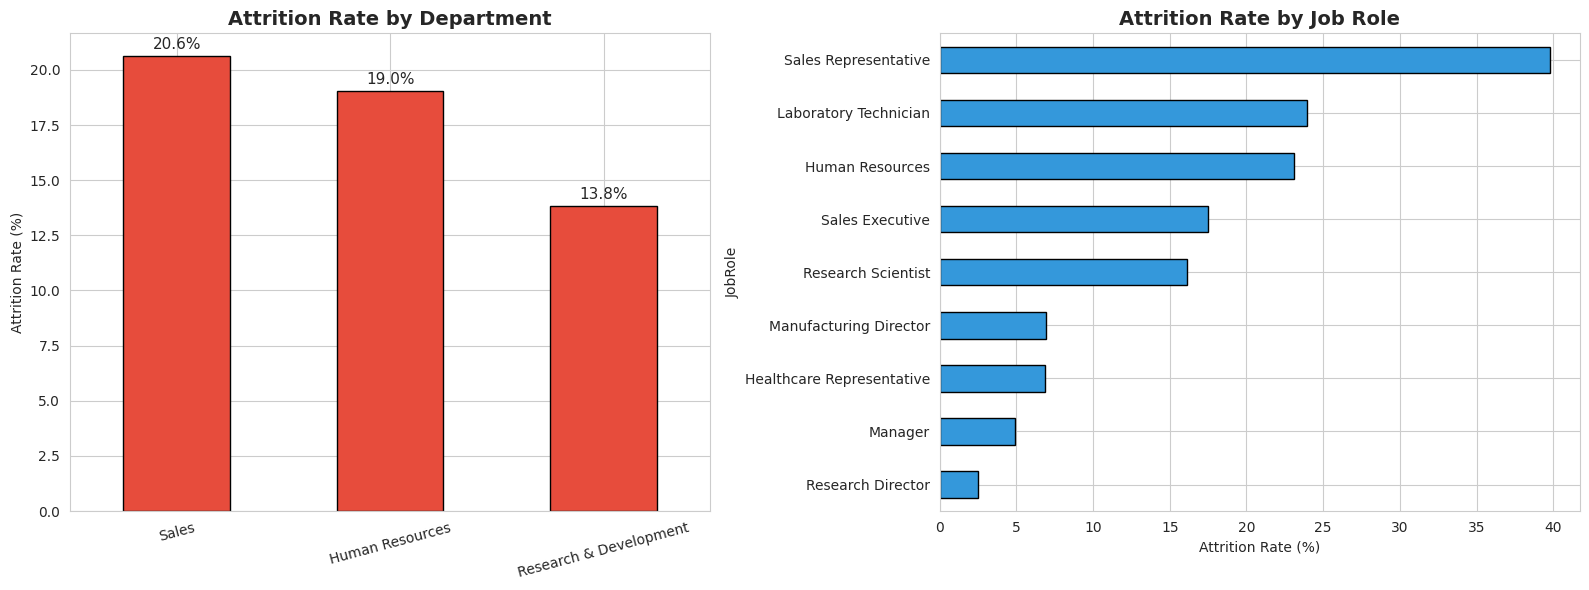

In [5]:
# Attrition by Department and Job Role
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

dept_attr = df.groupby('Department')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100).sort_values(ascending=False)
dept_attr.plot(kind='bar', ax=axes[0], color='#e74c3c', edgecolor='black')
axes[0].set_title('Attrition Rate by Department', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=15)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=11)

role_attr = df.groupby('JobRole')['Attrition'].apply(
    lambda x: (x == 'Yes').sum() / len(x) * 100).sort_values(ascending=True)
role_attr.plot(kind='barh', ax=axes[1], color='#3498db', edgecolor='black')
axes[1].set_title('Attrition Rate by Job Role', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Attrition Rate (%)')

plt.tight_layout()
plt.savefig('attrition_by_role.png', bbox_inches='tight', dpi=150)
plt.show()

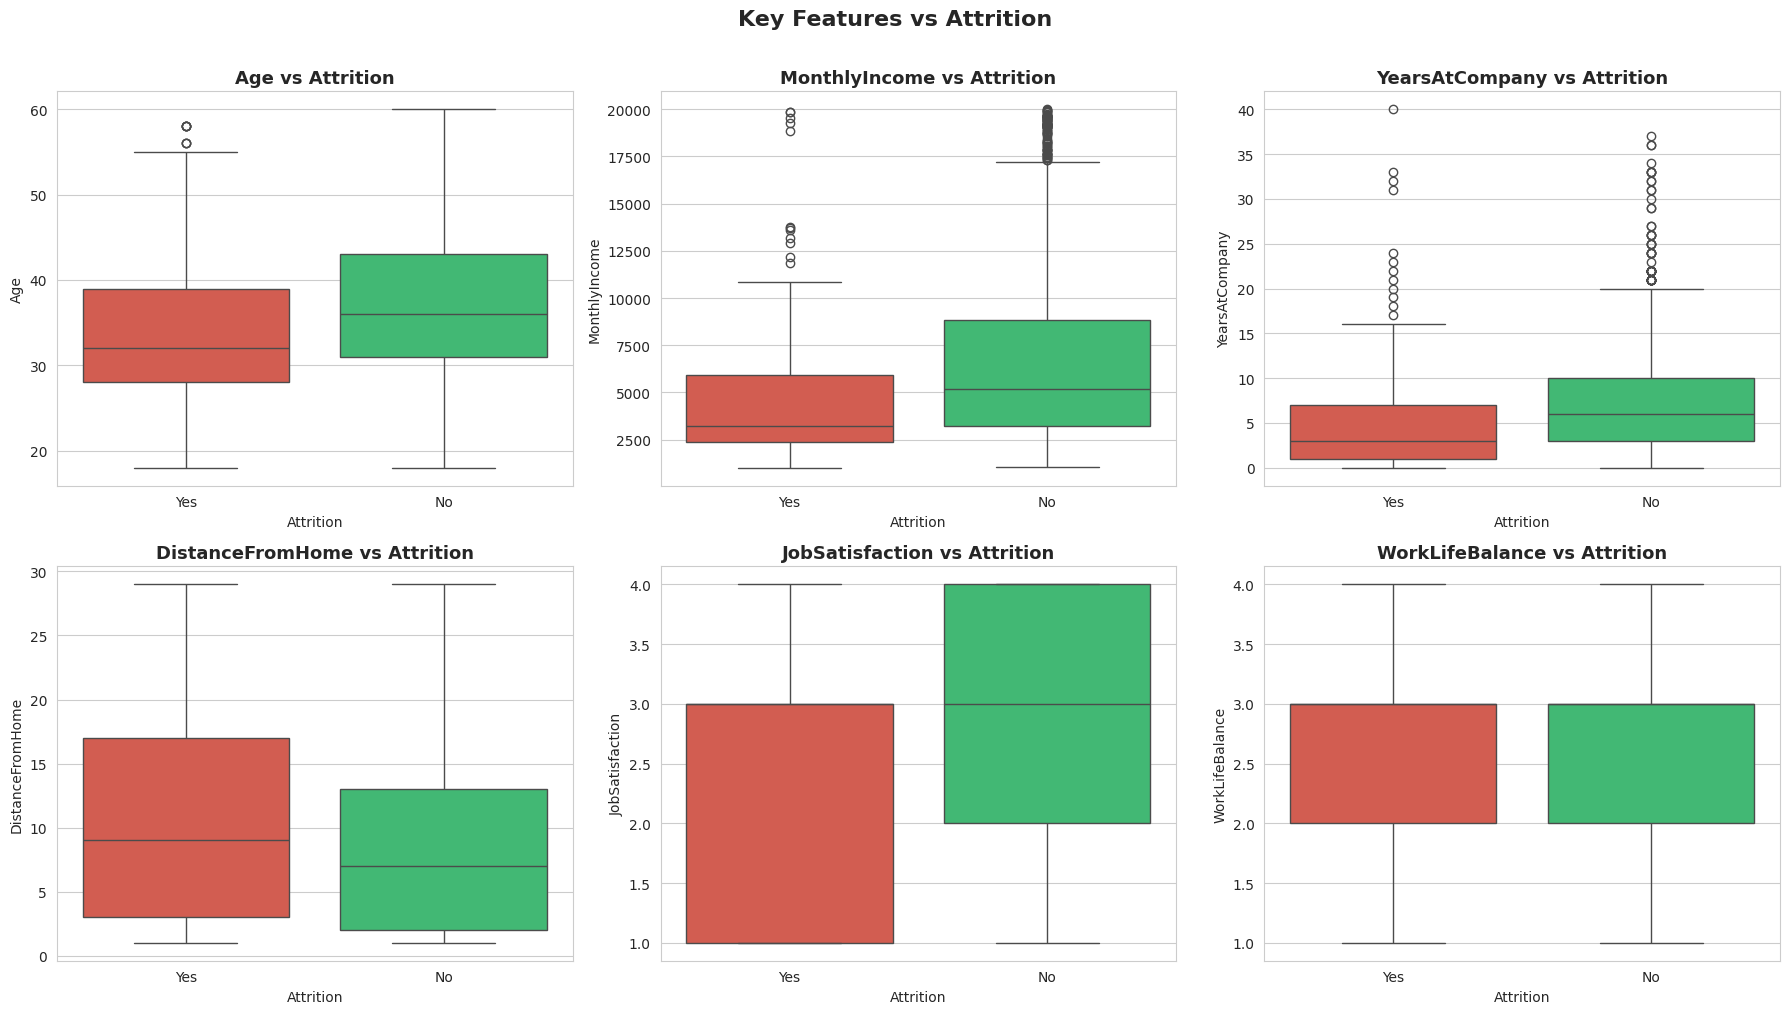

In [6]:
# Key numeric features vs Attrition
features = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'DistanceFromHome',
            'JobSatisfaction', 'WorkLifeBalance']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.boxplot(data=df, x='Attrition', y=feat,
                palette={'No': '#2ecc71', 'Yes': '#e74c3c'}, ax=axes[i])
    axes[i].set_title(f'{feat} vs Attrition', fontsize=13, fontweight='bold')

plt.suptitle('Key Features vs Attrition', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('features_vs_attrition.png', bbox_inches='tight', dpi=150)
plt.show()

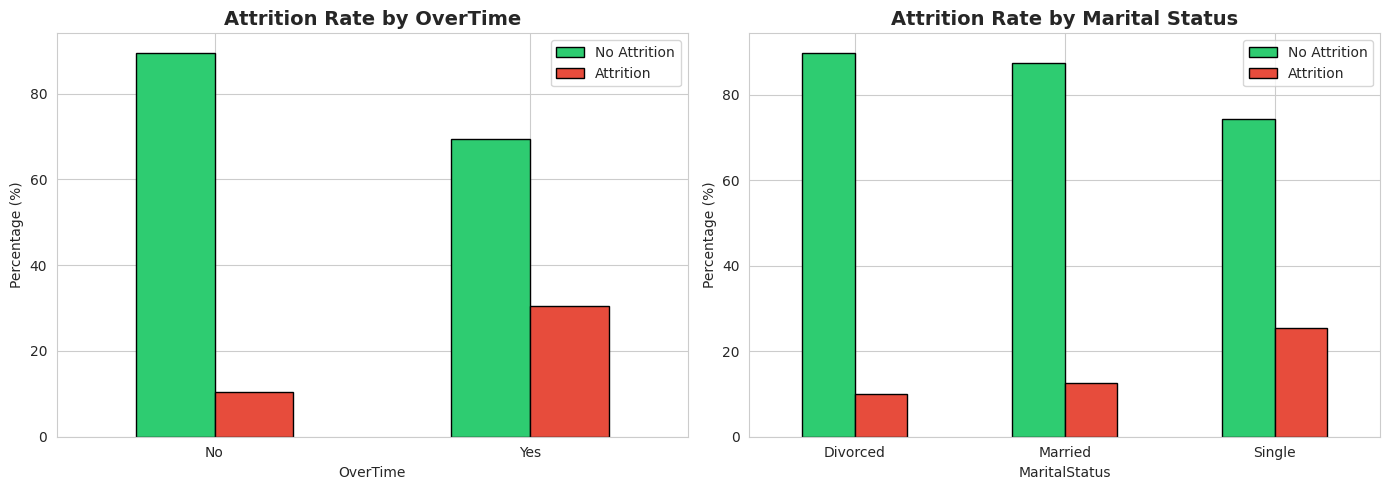

In [7]:
# OverTime impact
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

overtime_attr = pd.crosstab(df['OverTime'], df['Attrition'], normalize='index') * 100
overtime_attr.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Attrition Rate by OverTime', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Percentage (%)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(['No Attrition', 'Attrition'])

marital_attr = pd.crosstab(df['MaritalStatus'], df['Attrition'], normalize='index') * 100
marital_attr.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[1].set_title('Attrition Rate by Marital Status', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(['No Attrition', 'Attrition'])

plt.tight_layout()
plt.savefig('overtime_marital_attrition.png', bbox_inches='tight', dpi=150)
plt.show()

## 4. Data Preprocessing

In [8]:
# Drop columns with no variance or irrelevant to prediction
df_model = df.drop(['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours'], axis=1)

# Encode target variable
df_model['Attrition'] = df_model['Attrition'].map({'Yes': 1, 'No': 0})

# Encode categorical features
le = LabelEncoder()
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns to encode: {cat_cols}')

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

print(f'\nFinal dataset shape: {df_model.shape}')
print('✅ Preprocessing complete!')
df_model.head()

Categorical columns to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Final dataset shape: (1470, 31)
✅ Preprocessing complete!


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,2,0,...,3,1,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,3,1,...,4,4,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,4,1,...,3,2,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,4,0,...,3,3,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,1,...,3,4,1,6,3,3,2,2,2,2


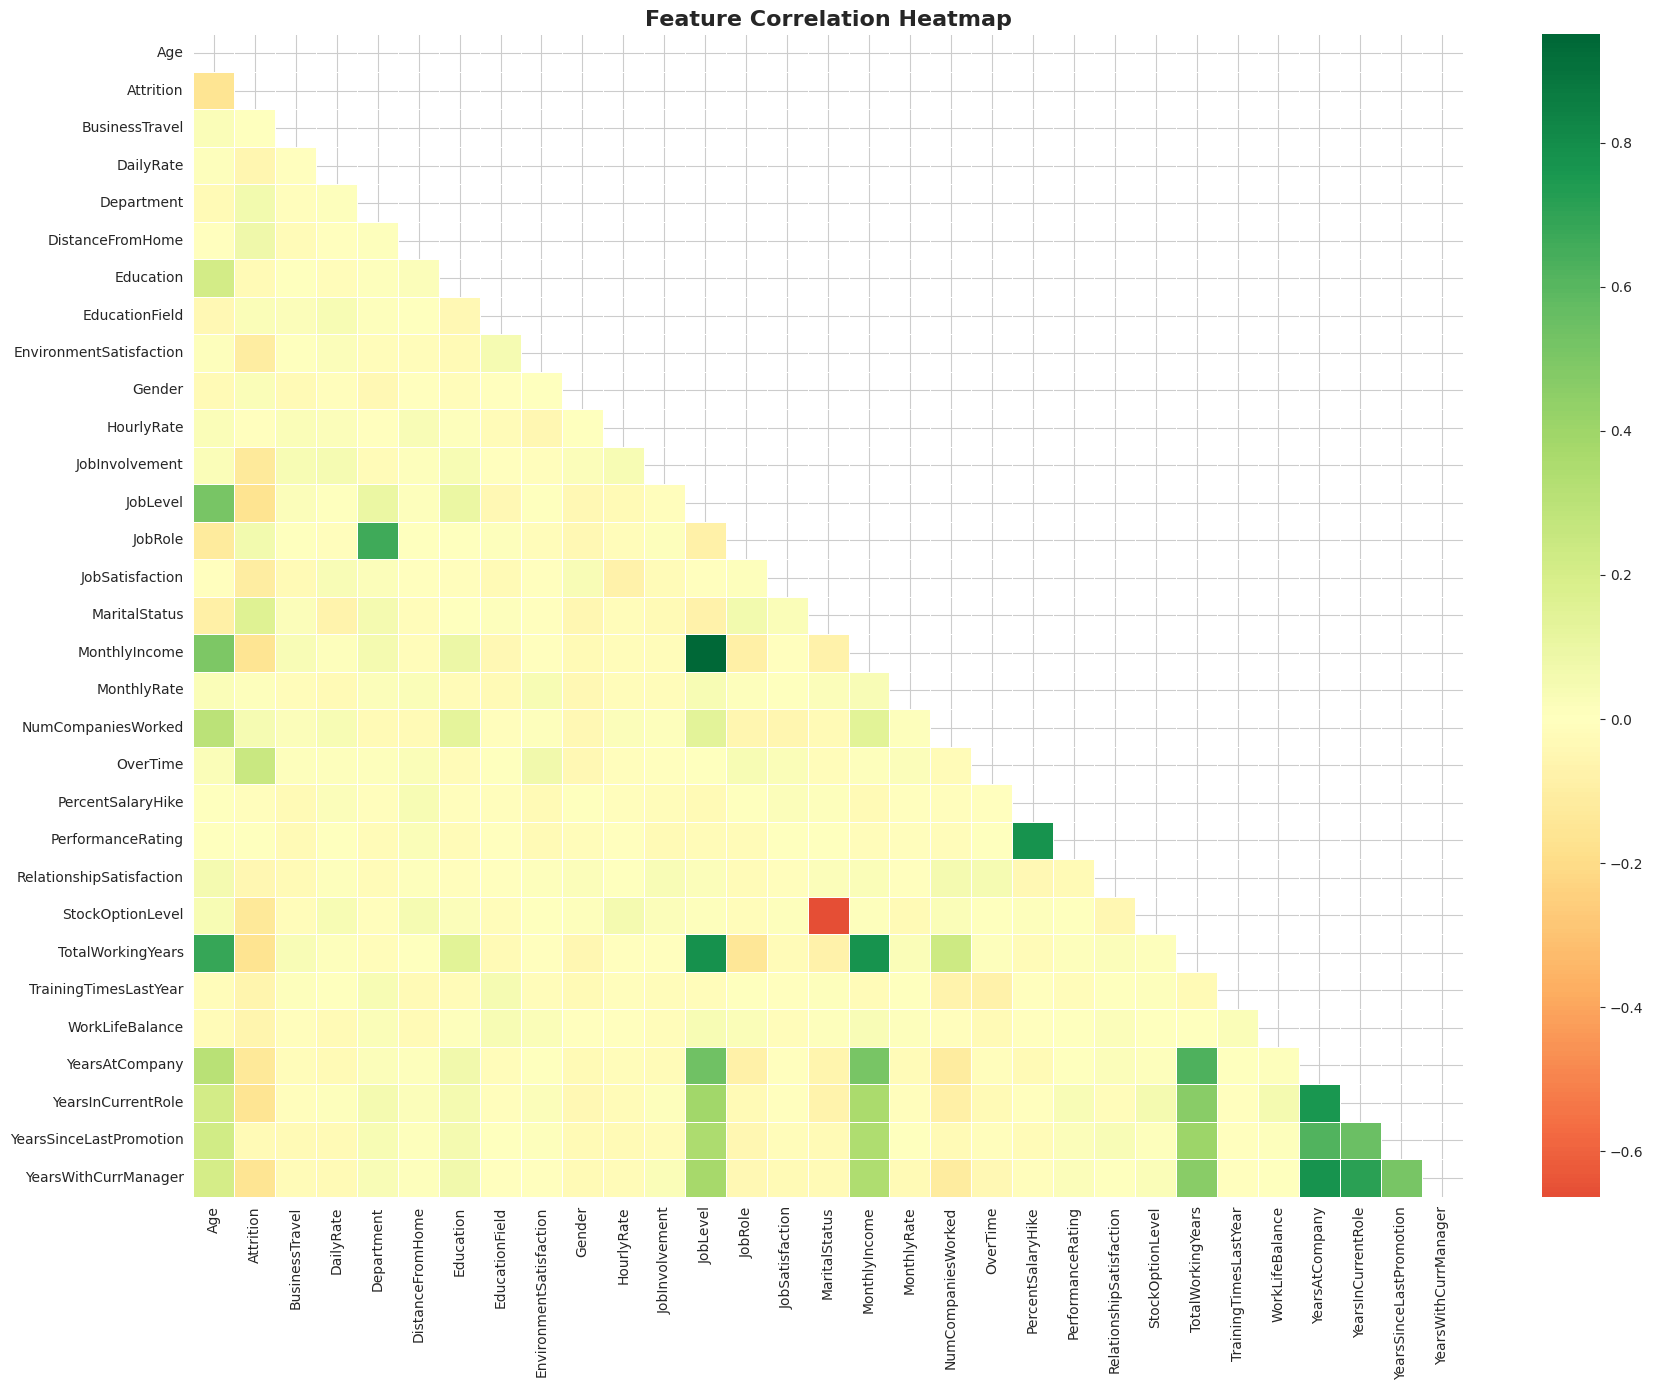

In [9]:
# Correlation Heatmap
plt.figure(figsize=(18, 14))
corr = df_model.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='RdYlGn',
            center=0, linewidths=0.5, fmt='.2f')
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

## 5. Model Training & Evaluation

In [10]:
# Train-test split
X = df_model.drop('Attrition', axis=1)
y = df_model['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')
print(f'Attrition rate in test: {y_test.mean()*100:.1f}%')

Training set: 1176 samples
Test set:     294 samples
Attrition rate in test: 16.0%


In [11]:
# Train 3 models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
}

results = {}
for name, model in models.items():
    X_tr = X_train_sc if name == 'Logistic Regression' else X_train
    X_te = X_test_sc  if name == 'Logistic Regression' else X_test
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    acc  = accuracy_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)
    results[name] = {'model': model, 'acc': acc, 'auc': auc,
                     'pred': y_pred, 'prob': y_prob}
    print(f'{name:25s} | Accuracy: {acc:.4f} | ROC-AUC: {auc:.4f}')

best_name = max(results, key=lambda k: results[k]['auc'])
print(f'\n🏆 Best Model: {best_name} (AUC: {results[best_name]["auc"]:.4f})')

Logistic Regression       | Accuracy: 0.8741 | ROC-AUC: 0.8057


Random Forest             | Accuracy: 0.8435 | ROC-AUC: 0.7890


Gradient Boosting         | Accuracy: 0.8401 | ROC-AUC: 0.7969

🏆 Best Model: Logistic Regression (AUC: 0.8057)


In [12]:
# Detailed report for best model
best = results[best_name]
print(f'=== {best_name} — Classification Report ===')
print(classification_report(y_test, best['pred'], target_names=['No Attrition', 'Attrition']))

=== Logistic Regression — Classification Report ===
              precision    recall  f1-score   support

No Attrition       0.89      0.97      0.93       247
   Attrition       0.69      0.38      0.49        47

    accuracy                           0.87       294
   macro avg       0.79      0.68      0.71       294
weighted avg       0.86      0.87      0.86       294



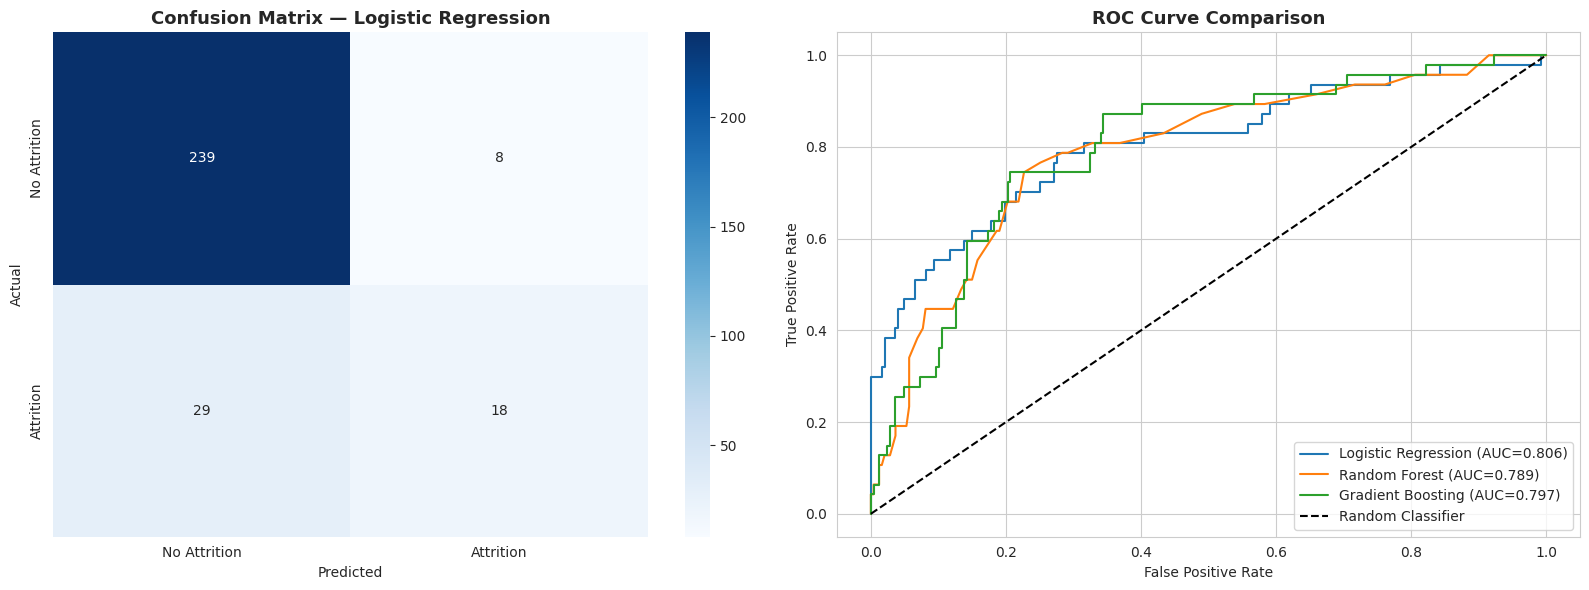

In [13]:
# Confusion Matrix + ROC Curve side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix
cm = confusion_matrix(y_test, best['pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Attrition', 'Attrition'],
            yticklabels=['No Attrition', 'Attrition'])
axes[0].set_title(f'Confusion Matrix — {best_name}', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curves
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['prob'])
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.3f})")
axes[1].plot([0,1],[0,1],'k--', label='Random Classifier')
axes[1].set_title('ROC Curve Comparison', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('model_evaluation.png', bbox_inches='tight', dpi=150)
plt.show()

## 6. Feature Importance

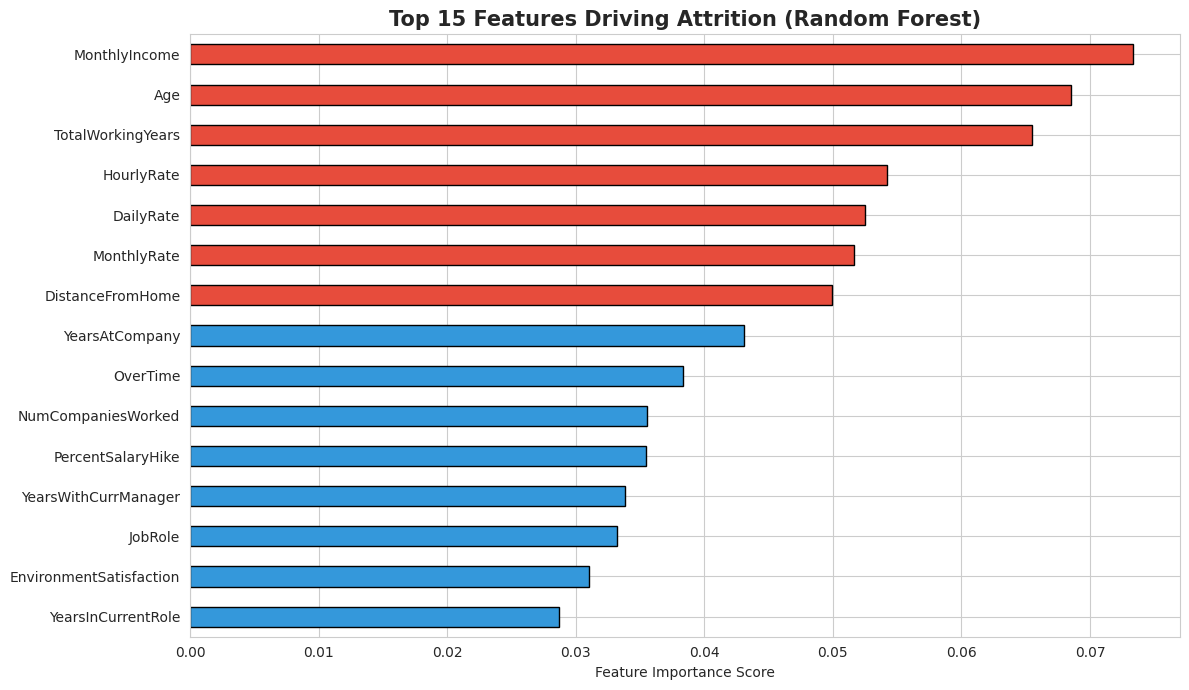

Top 5 most important features:
  MonthlyIncome                      : 0.0733
  Age                                : 0.0686
  TotalWorkingYears                  : 0.0655
  HourlyRate                         : 0.0542
  DailyRate                          : 0.0525


In [14]:
# Feature importance from Random Forest
rf = results['Random Forest']['model']
importances = pd.Series(rf.feature_importances_, index=X.columns)
top15 = importances.nlargest(15).sort_values()

plt.figure(figsize=(12, 7))
colors = ['#e74c3c' if v > top15.median() else '#3498db' for v in top15]
top15.plot(kind='barh', color=colors, edgecolor='black')
plt.title('Top 15 Features Driving Attrition (Random Forest)', fontsize=15, fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

print('Top 5 most important features:')
for feat, score in importances.nlargest(5).items():
    print(f'  {feat:35s}: {score:.4f}')

## 7. Key Business Insights

In [15]:
print('=' * 55)
print('   IBM HR ATTRITION — KEY BUSINESS INSIGHTS')
print('=' * 55)

attr_rate = df['Attrition'].value_counts(normalize=True)['Yes'] * 100
print(f'\n📊 Overall Attrition Rate       : {attr_rate:.1f}%')

ot_yes = df[df['OverTime']=='Yes']['Attrition'].value_counts(normalize=True)['Yes']*100
ot_no  = df[df['OverTime']=='No']['Attrition'].value_counts(normalize=True)['Yes']*100
print(f'⏰ OverTime employees leaving    : {ot_yes:.1f}% vs {ot_no:.1f}% (no overtime)')

single = df[df['MaritalStatus']=='Single']['Attrition'].value_counts(normalize=True)['Yes']*100
print(f'💍 Single employees leaving      : {single:.1f}% (highest among marital groups)')

dept_rates = df.groupby('Department')['Attrition'].apply(
    lambda x: (x=='Yes').sum()/len(x)*100)
print(f'\n🏢 Attrition by Department:')
for dept, rate in dept_rates.sort_values(ascending=False).items():
    print(f'   {dept:30s}: {rate:.1f}%')

low_income = df[df['MonthlyIncome'] < df['MonthlyIncome'].quantile(0.25)]
low_attr = (low_income['Attrition']=='Yes').mean()*100
print(f'\n💰 Low income employees leaving  : {low_attr:.1f}%')

print(f'\n🤖 Best ML Model                : {best_name}')
print(f'   Accuracy                     : {best["acc"]*100:.2f}%')
print(f'   ROC-AUC Score                : {best["auc"]:.4f}')
print('\n✅ Analysis Complete!')

   IBM HR ATTRITION — KEY BUSINESS INSIGHTS

📊 Overall Attrition Rate       : 16.1%
⏰ OverTime employees leaving    : 30.5% vs 10.4% (no overtime)
💍 Single employees leaving      : 25.5% (highest among marital groups)

🏢 Attrition by Department:
   Sales                         : 20.6%
   Human Resources               : 19.0%
   Research & Development        : 13.8%

💰 Low income employees leaving  : 29.4%

🤖 Best ML Model                : Logistic Regression
   Accuracy                     : 87.41%
   ROC-AUC Score                : 0.8057

✅ Analysis Complete!


## 8. Conclusion

### Key Findings:
- **Attrition rate is 16.1%** — significantly impacting workforce stability
- **OverTime** is the strongest behavioural driver of attrition
- **Sales department** has the highest attrition rate among all departments
- **Single employees** leave at a higher rate than married or divorced
- **Lower monthly income** strongly correlates with higher attrition
- **Monthly Income, Age, and Total Working Years** are the top predictive features

### Recommendations:
1. **Review overtime policies** — reduce mandatory overtime especially in Sales
2. **Salary benchmarking** — audit compensation for bottom quartile earners
3. **Targeted retention programs** for young, single employees early in their careers
4. **Job satisfaction surveys** — proactively identify at-risk employees
